# Análise de Performance do KubeTimer Operator

**Data do experimento:** 23 de março de 2026  
**Cluster:** Minikube (single-node)  
**Versão do operador:** v0.2.0  

Este notebook analisa os resultados de dois experimentos complementares executados contra o operador KubeTimer:

| Experimento | Modo | Réplicas | Deploys criados | Taxa máxima |
|---|---|---|---|---|
| A | Zero-replica | 0 | 11.400 | 20 dep/s |
| B | Com pods | 1 | 2.910 | 4 dep/s |

O modo **zero-replica** isola o desempenho do operador (apenas objetos API, sem scheduling de pods).  
O modo **com pods** testa o cenário realista onde cada Deployment gera ReplicaSet + Pod, amplificando a carga no API Server.

Os snapshots de métricas são **cumulativos** (counters do Prometheus nunca resetam entre fases). Para obter valores por fase, calculamos deltas: $\Delta_{\text{fase}} = \text{snapshot}_{n} - \text{snapshot}_{n-1}$.

## Metodologia: Pipeline de Coleta e Transformação das Métricas

Este notebook utiliza dados que passaram por **três estágios de transformação** antes de se tornarem gráficos. A seguir, detalhamos cada etapa para cada métrica relevante.

---

### Estágio 1 — Instrumentação no Operador (`instruments.py`)

O operador KubeTimer registra métricas usando a biblioteca `prometheus_client` do Python. Os instrumentos relevantes são:

| Métrica Prometheus | Tipo | Labels | O que mede |
|---|---|---|---|
| `kubetimer_delete_duration_seconds` | **Histogram** | `source`, `namespace` | Tempo de cada chamada `DELETE` à API do K8s |
| `kubetimer_event_handler_duration_seconds` | **Histogram** | `event_type` | Tempo total dentro de cada handler Kopf (create/update/delete) |
| `kubetimer_deployments_deleted_total` | **Counter** | `source`, `namespace`, `outcome` | Contagem cumulativa de deleções tentadas |

**Histograms** funcionam internamente como um conjunto de buckets. A cada observação (e.g., uma chamada DELETE que levou 8 ms), o Prometheus incrementa todos os buckets cujo limite superior ≥ 0,008s. Os buckets configurados para `kubetimer_delete_duration_seconds` são:

```
(0.005, 0.01, 0.025, 0.05, 0.1, 0.25, 0.5, 1, 2.5, 5, 10, 30, 60)
```

O Prometheus expõe automaticamente três séries temporais para cada Histogram:
- `kubetimer_delete_duration_seconds_bucket{le="..."}` — contagem acumulada por bucket
- `kubetimer_delete_duration_seconds_sum` — soma total dos valores observados
- `kubetimer_delete_duration_seconds_count` — contagem total de observações

**Counters** são monotonicamente crescentes e nunca resetam (a menos que o pod reinicie). O valor em qualquer instante é o **acumulado total desde o último restart**.

A instrumentação ocorre via context managers (`track_duration`, `track_concurrency`) nos handlers:
- `on_deployment_created_with_ttl`: observa `EVENT_HANDLER_DURATION{event_type="create"}` e, se o TTL já expirou, observa `DELETE_DURATION{source="event_handler"}` + incrementa `DEPLOYMENTS_DELETED{source="event_handler", outcome="deleted"}`
- `on_ttl_annotation_changed`: observa `EVENT_HANDLER_DURATION{event_type="update"}`
- `on_deployment_deleted_with_ttl`: observa `EVENT_HANDLER_DURATION{event_type="delete"}`
- `delete_deployment_job` (APScheduler): observa `DELETE_DURATION{source="scheduler"}` + incrementa `DEPLOYMENTS_DELETED{source="scheduler"}`
- `bulk_delete` (reconciliação): observa `DELETE_DURATION{source="reconciler"}` + incrementa `DEPLOYMENTS_DELETED{source="reconciler"}`

---

### Estágio 2 — Snapshot via PromQL (`experiment.py → snapshot_metrics()`)

Ao final de cada fase do experimento, o script `experiment.py` executa queries PromQL instantâneas contra o Prometheus e salva os resultados em JSON/CSV.

#### `kubetimer_delete_duration_seconds` → Percentis de Latência

A query usada para cada percentil é:

```promql
histogram_quantile(<pct>, sum(rate(kubetimer_delete_duration_seconds_bucket[5m])) by (le))
```

**Decomposição passo a passo:**

1. **`kubetimer_delete_duration_seconds_bucket[5m]`** — seleciona os últimos 5 minutos de amostras de cada bucket.
2. **`rate(...[5m])`** — calcula a taxa de incremento por segundo de cada bucket na janela de 5 minutos. Isso transforma contadores cumulativos em taxas instantâneas.
3. **`sum(...) by (le)`** — agrega todas as labels (source, namespace) mantendo apenas `le` (limite do bucket), resultando na distribuição global.
4. **`histogram_quantile(pct, ...)`** — interpola linearmente entre os buckets para estimar o valor do percentil solicitado.

Os percentis calculados e seus campos no JSON:

| `pct` | Campo no JSON | Significado |
|---|---|---|
| 0.95 | `delete_latency_p95_s` | 95% das deleções foram mais rápidas que este valor |
| 0.99 | `delete_latency_p99_s` | 99% das deleções foram mais rápidas que este valor |
| 1.0 | `delete_latency_max_s` | Estimativa do valor máximo |
| 0.0 | `delete_latency_min_s` | Estimativa do valor mínimo |

**Nota importante:** Os percentis são calculados sobre uma **janela deslizante de 5 minutos** (`rate(...[5m])`). Isso significa que o valor capturado ao final de cada fase reflete o comportamento recente, não apenas o da fase em questão. Fases mais curtas que 5 minutos terão seus percentis influenciados pela fase anterior.

#### `kubetimer_deployments_deleted_total` → Contadores Cumulativos

```promql
sum(kubetimer_deployments_deleted_total{source="event_handler"})
sum(kubetimer_deployments_deleted_total{source="scheduler"})
sum(kubetimer_deployments_deleted_total{outcome="deleted"})
sum(kubetimer_deployments_deleted_total{outcome="error"})
```

Cada query retorna o **valor acumulado total do counter naquele instante** (não uma taxa). O `sum()` agrega todas as labels que não são filtradas (e.g., todas as namespaces).

Os campos no JSON: `total_deletions_event_handler`, `total_deletions_scheduler`, `total_outcome_deleted`, `total_outcome_error`.

#### `kubetimer_event_handler_duration_seconds`

Esta métrica **não é consultada diretamente** pelo `experiment.py`, portanto não aparece nos JSONs. Ela é útil para debugging operacional (dashboards Grafana) mas não é usada nesta análise.

---

### Estágio 3 — Transformações no Notebook (`analysis.ipynb`)

#### Latência (Seção 1)

Os valores `delete_latency_p95_s` e `delete_latency_p99_s` do JSON são **usados diretamente**, apenas convertidos de segundos para milissegundos (× 1000) para facilitar a leitura nos gráficos.

Nenhuma transformação adicional é aplicada — os valores já representam percentis calculados pelo Prometheus.

#### Throughput de Deleções (Seção 2)

Os counters `total_deletions_event_handler` e `total_deletions_scheduler` são **cumulativos entre fases e entre runs**. Para obter o throughput específico de cada fase, aplicamos:

**1. Cálculo de deltas (Δ):** Para cada counter cumulativo, calculamos a diferença entre fases consecutivas:

$$\Delta_{\text{fase}_n} = \text{counter}_{\text{fase}_n} - \text{counter}_{\text{fase}_{n-1}}$$

Implementação: `np.diff(vals, prepend=vals[0])`, que produz delta = 0 para a fase 1 (sem referência anterior válida).

**2. Conversão para taxa:** Dividimos o delta pela duração da fase:

$$\text{throughput}_{\text{fase}} = \frac{\Delta_{\text{deletions}}}{\text{duration\_s}}$$

**3. Exclusão da fase 1:** Como os counters do Prometheus acumulam entre runs (sem reset), o valor absoluto da fase 1 inclui todos os runs anteriores. Sem um snapshot pré-experimento, não é possível calcular o delta real da fase 1, que portanto é excluída do gráfico de throughput.

#### CPU e Memória (Seções 3 e 4)

As métricas de CPU e memória vêm do **cAdvisor** (não do operador), capturadas via:

```promql
sum(rate(container_cpu_usage_seconds_total{...}[1m]))      → cpu_cores
sum(container_memory_working_set_bytes{...})                → memory_bytes
```

- **CPU:** O valor `cpu_cores` já é uma taxa (cores/segundo). No notebook, multiplicamos por 1000 para exibir em **millicores (m)**.
- **Memória:** O valor `memory_bytes` é absoluto (bytes). No notebook, dividimos por 1024² (= 1.048.576) para exibir em **MiB (Mi)**, a unidade binária padrão do Kubernetes.

In [17]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

# Carregar dados
with open('experiment_20260323_202809_zero_replicas.json') as f:
    raw_zero = json.load(f)
with open('experiment_20260323_193128_with_pods.json') as f:
    raw_pods = json.load(f)

def build_df(raw):
    rows = []
    for entry in raw:
        row = {
            'phase': entry['phase'],
            'duration_s': entry['duration_seconds'],
            'created': entry['deployments_created'],
            'remaining': entry['deployments_remaining'],
        }
        row.update(entry['metrics_snapshot'])
        rows.append(row)
    return pd.DataFrame(rows)

df_zero = build_df(raw_zero)
df_pods = build_df(raw_pods)

# Nomes curtos para exibição
phase_labels = {
    '1_warmup': 'Aquecimento\nEquilibrado',
    '2_sustained_load': 'Carga\nSustentada',
    '3_burst': 'Burst de\nexclusão',
    '4_cooldown': 'Cooldown',
    '6_scale_burst': 'Burst\nProlongado',
    '7_mixed_future': 'Agendamento\nprolongado',
    '8_final_cooldown': 'Cooldown\nprolongado',
}
df_zero['label'] = df_zero['phase'].map(phase_labels)
df_pods['label'] = df_pods['phase'].map(phase_labels)

print(f'Zero-replica: {len(df_zero)} fases, {df_zero["created"].sum()} deploys criados')
print(f'Com pods:     {len(df_pods)} fases, {df_pods["created"].sum()} deploys criados')

Zero-replica: 7 fases, 11400 deploys criados
Com pods:     7 fases, 2910 deploys criados


## 0. Perfil de Carga do Experimento

Para contextualizar os resultados das seções seguintes, este gráfico mostra a **taxa de criação** (área colorida) e a **taxa estimada de deleção** (linha tracejada vermelha) de Deployments ao longo do tempo. Cada fase é representada por uma cor distinta, com duração proporcional no eixo temporal. Os losangos no eixo secundário indicam o **backlog** — quantos Deployments com TTL restavam ao final de cada fase.

A taxa de deleção por fase é estimada a partir dos dados do experimento, sem depender dos counters Prometheus:

$$\text{deleções}_\text{fase} = \text{criados}_\text{fase} + \text{restantes}_\text{início} - \text{restantes}_\text{fim}$$

A anotação `(X% past)` em cada fase indica a fração de TTLs que já nascem expirados — gerando deleção imediata via event handler. As fases cooldown não criam Deployments (taxa = 0); o operador drena o backlog restante.

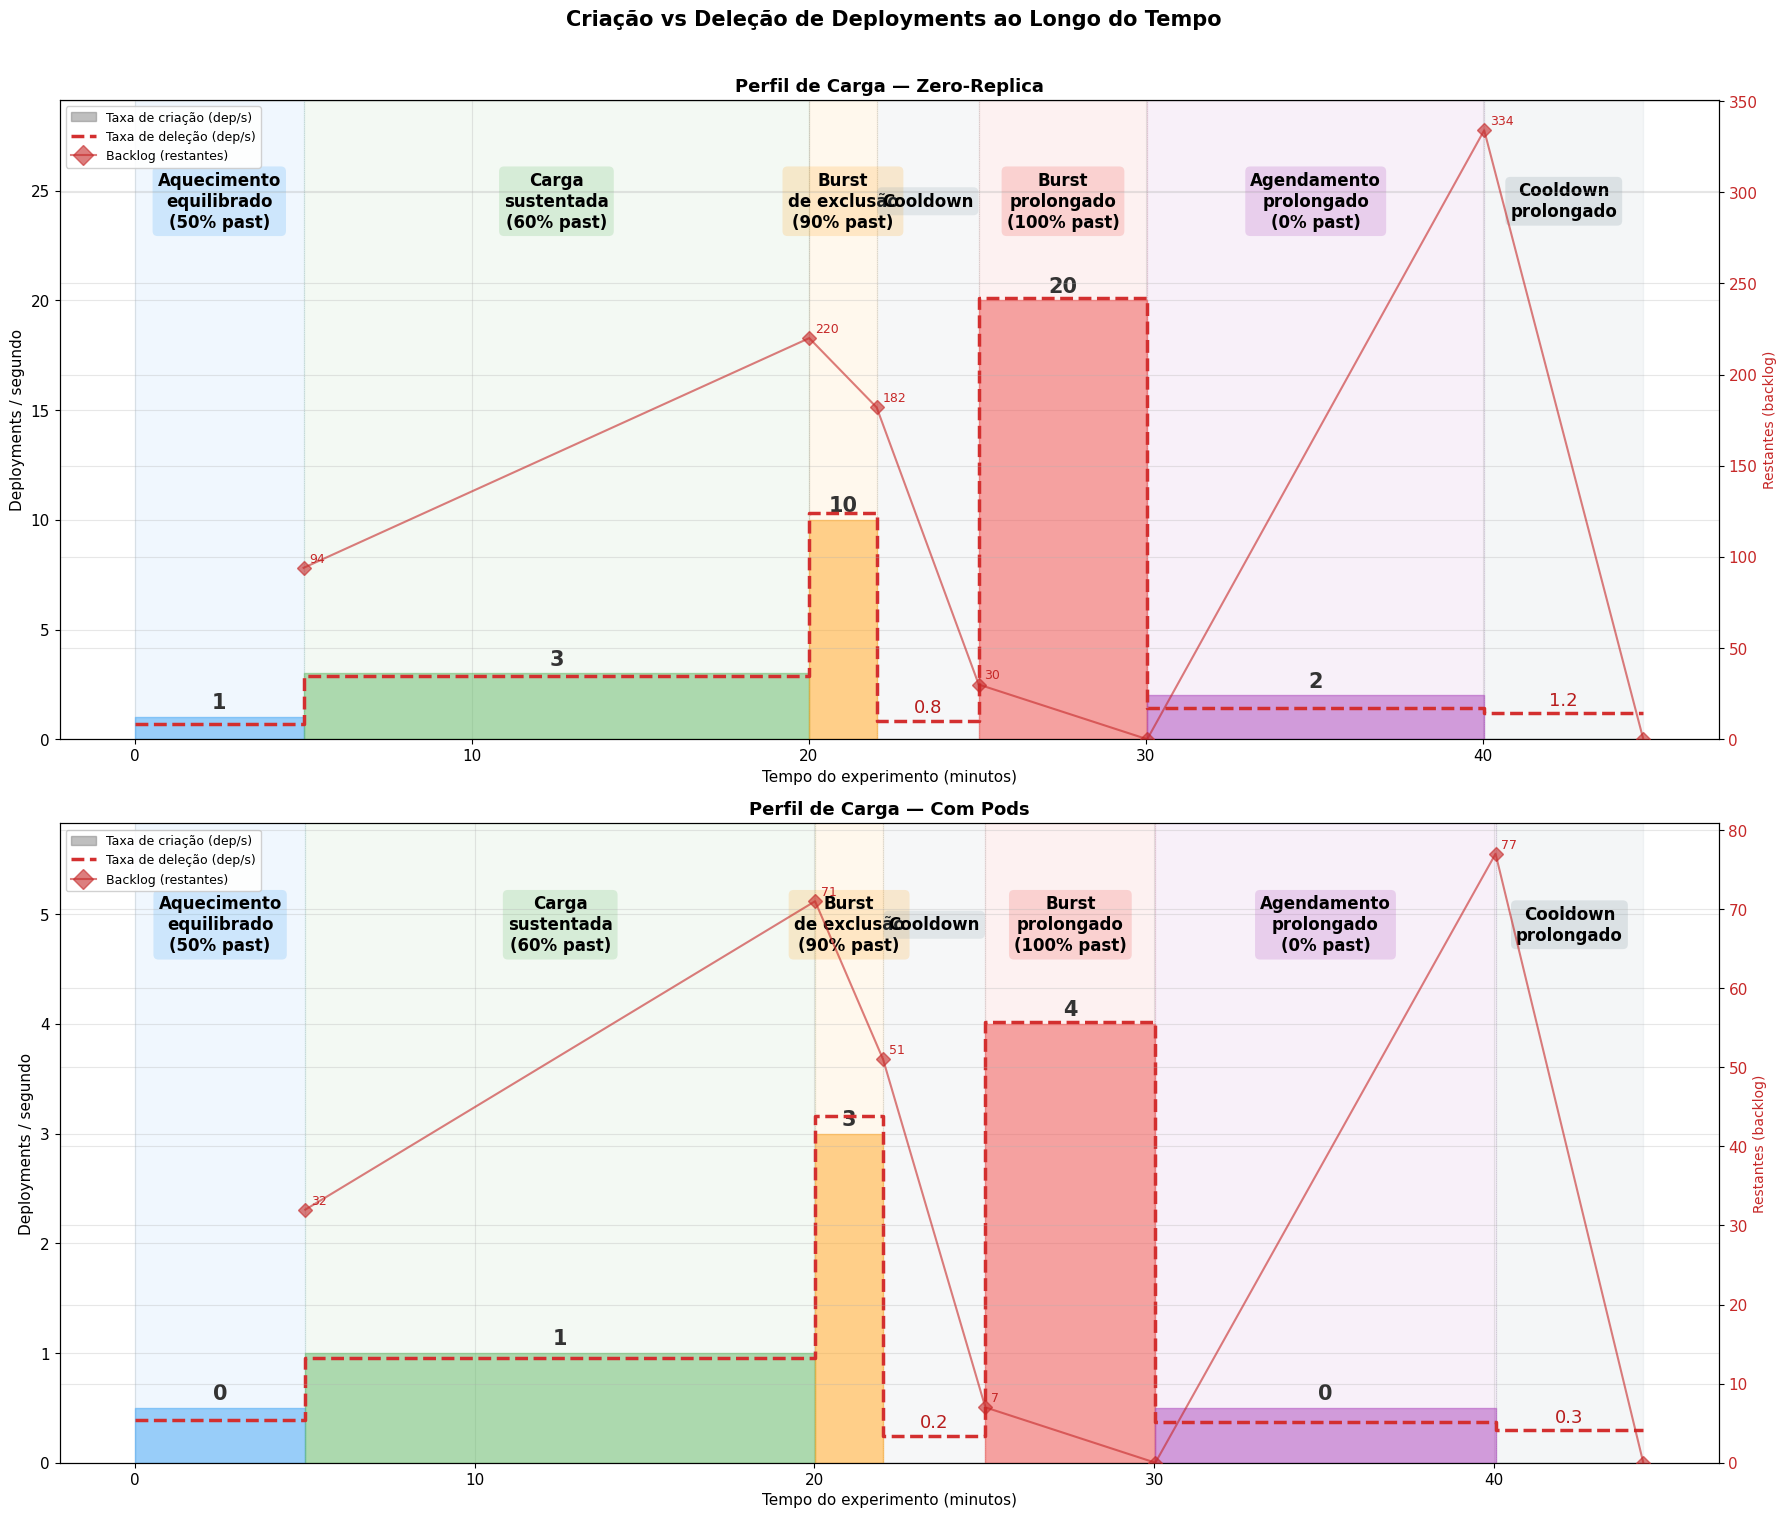

In [2]:
import matplotlib.patches as mpatches

# Configuração visual por fase: cor, rótulo (com past_ratio), past_ratio
phase_styles = {
    '1_warmup':          {'color': '#42A5F5', 'label': 'Aquecimento\nequilibrado\n(50% past)'},
    '2_sustained_load':  {'color': '#66BB6A', 'label': 'Carga\nsustentada\n(60% past)'},
    '3_burst':           {'color': '#FFA726', 'label': 'Burst\nde exclusão\n(90% past)'},
    '4_cooldown':        {'color': '#90A4AE', 'label': 'Cooldown'},
    '6_scale_burst':     {'color': '#EF5350', 'label': 'Burst\nprolongado\n(100% past)'},
    '7_mixed_future':    {'color': '#AB47BC', 'label': 'Agendamento\nprolongado\n(0% past)'},
    '8_final_cooldown':  {'color': '#78909C', 'label': 'Cooldown\nprolongado'},
}

def plot_load_profile(ax, df, title):
    """Plota o perfil de criação vs deleção ao longo do tempo."""
    phases = []
    t = 0
    prev_remaining = 0
    for _, row in df.iterrows():
        dur_min = row['duration_s'] / 60
        cr = row['created'] / row['duration_s'] if row['duration_s'] > 0 else 0
        deletions = row['created'] + prev_remaining - row['remaining']
        dr = max(0, deletions / row['duration_s']) if row['duration_s'] > 0 else 0
        phases.append({
            'phase': row['phase'], 't0': t, 't1': t + dur_min,
            'cr': cr, 'dr': dr, 'remaining': row['remaining'],
        })
        t += dur_min
        prev_remaining = row['remaining']

    y_max = max(max(p['cr'], p['dr']) for p in phases)

    for p in phases:
        s = phase_styles[p['phase']]
        t0, t1 = p['t0'], p['t1']
        mid = (t0 + t1) / 2

        # Faixa de fundo colorida
        ax.axvspan(t0, t1, alpha=0.08, color=s['color'], zorder=0)

        # Área preenchida = taxa de criação
        ax.fill_between([t0, t1], 0, [p['cr'], p['cr']],
                        alpha=0.5, color=s['color'], zorder=2)

        # Rótulo da fase no topo
        ax.text(mid, y_max * 1.22, s['label'],
                ha='center', va='center', fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=s['color'],
                          alpha=0.2, edgecolor='none'))

        # Anotar taxa de criação (ou deleção em cooldowns)
        if p['cr'] > 0:
            ax.annotate(f'{p["cr"]:.0f}', xy=(mid, p['cr']),
                        xytext=(0, 6), textcoords='offset points',
                        ha='center', fontsize=15, fontweight='bold', color='#333')
        elif p['dr'] > 0:
            ax.annotate(f'{p["dr"]:.1f}', xy=(mid, p['dr']),
                        xytext=(0, 6), textcoords='offset points',
                        ha='center', fontsize=13, color='#B71C1C')

        # Linhas divisórias entre fases
        if t0 > 0:
            ax.axvline(x=t0, color='gray', linewidth=0.5, linestyle=':', alpha=0.4, zorder=1)

    # Linha tracejada = taxa de deleção (step function)
    t_step, dr_step = [], []
    for p in phases:
        t_step.extend([p['t0'], p['t1']])
        dr_step.extend([p['dr'], p['dr']])
    ax.plot(t_step, dr_step, color='#D32F2F', linewidth=2.5, linestyle='--', zorder=7)

    # Eixo secundário: backlog (restantes)
    ax2 = ax.twinx()
    t_ends = [p['t1'] for p in phases]
    remaining = [p['remaining'] for p in phases]
    ax2.plot(t_ends, remaining, 'D-', color='#C62828', linewidth=1.5,
             markersize=7, alpha=0.6, zorder=4)
    ax2.set_ylabel('Restantes (backlog)', color='#C62828', fontsize=10)
    ax2.tick_params(axis='y', labelcolor='#C62828')
    ax2.set_ylim(bottom=0)
    for i, (tx, rem) in enumerate(zip(t_ends, remaining)):
        if rem > 0:
            ax2.annotate(f'{int(rem)}', xy=(tx, rem), xytext=(4, 4),
                         textcoords='offset points', fontsize=9, color='#C62828')

    # Legenda
    create_patch = mpatches.Patch(color='gray', alpha=0.5, label='Taxa de criação (dep/s)')
    delete_line = plt.Line2D([0], [0], color='#D32F2F', linewidth=2.5,
                              linestyle='--', label='Taxa de deleção (dep/s)')
    remain_line = plt.Line2D([0], [0], color='#C62828', linewidth=1.5,
                              marker='D', markersize=10, alpha=0.6, label='Backlog (restantes)')
    ax.legend(handles=[create_patch, delete_line, remain_line],
              loc='upper left', fontsize=9, framealpha=0.9)

    ax.set_ylabel('Deployments / segundo', fontsize=11)
    ax.set_xlabel('Tempo do experimento (minutos)', fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_ylim(0, y_max * 1.45)

fig, (ax_z, ax_p) = plt.subplots(2, 1, figsize=(18, 15))
plot_load_profile(ax_z, df_zero, 'Perfil de Carga — Zero-Replica')
plot_load_profile(ax_p, df_pods, 'Perfil de Carga — Com Pods')
fig.suptitle('Criação vs Deleção de Deployments ao Longo do Tempo',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 1. Latência de Deleção por Fase

A latência de deleção (`kubetimer_delete_duration_seconds`) mede o tempo de cada chamada `DELETE` à API do Kubernetes. Analisamos os percentis p50 (mediana), p95 e p99 ao final de cada fase.

**Hipótese:** O modo com pods deve apresentar latências superiores, pois o API Server precisa processar a cascata de deleção (Deployment → ReplicaSet → Pod), e o `terminationGracePeriodSeconds` adiciona overhead.

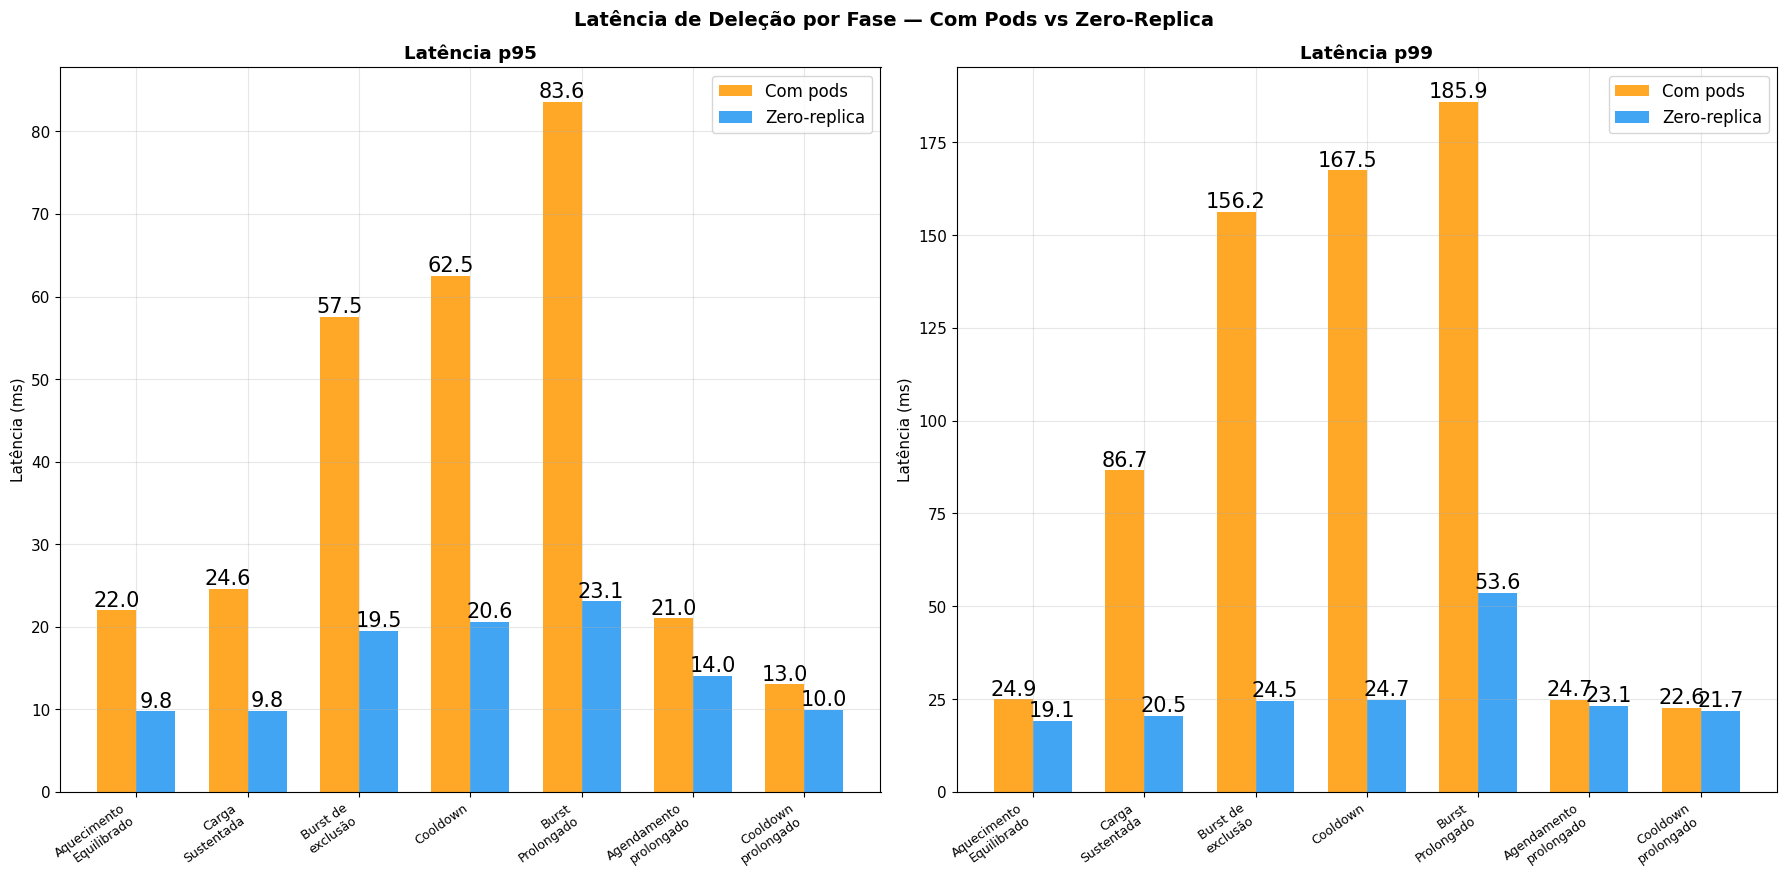

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9), sharey=False)

for ax, (col, title) in zip(axes, [
    ('delete_latency_p95_s', 'Latência p95'),
    ('delete_latency_p99_s', 'Latência p99'),
]):
    x = np.arange(len(df_pods))
    w = 0.35
    bars1 = ax.bar(x - w/2, df_pods[col] * 1000, w, label='Com pods', color='#FF9800', alpha=0.85)
    bars2 = ax.bar(x + w/2, df_zero[col] * 1000, w, label='Zero-replica', color='#2196F3', alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Latência (ms)')
    ax.set_xticks(x)
    ax.set_xticklabels(df_pods['label'], rotation=35, ha='right', fontsize=9)
    ax.legend(fontsize=12)

    for bar in bars1:
        h = bar.get_height()
        if h > 0:
            ax.annotate(f'{h:.1f}', xy=(bar.get_x() + bar.get_width()/2, h),
                        xytext=(0, 3), textcoords='offset points', ha='center', fontsize=15)
    for bar in bars2:
        h = bar.get_height()
        if h > 0:
            ax.annotate(f'{h:.1f}', xy=(bar.get_x() + bar.get_width()/2, h),
                        xytext=(0, 3), textcoords='offset points', ha='center', fontsize=15)

fig.suptitle('Latência de Deleção por Fase — Com Pods vs Zero-Replica', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretação da Latência

Os resultados confirmam a hipótese:

- **No modo zero-replica**, a mediana (p50) mantém-se entre **4,6 ms** (cool-down final) e **7,9 ms** (burst extremo) — oscilação de apenas ~1,7×, mesmo com a taxa de criação variando de 0 a 20 dep/s. Isto demonstra que a latência do DELETE à API é estável.

- **No modo com pods**, a p50 é consistentemente mais alta: atinge **19,5 ms** no burst extremo (2,5× pior que zero-replica na mesma fase). O p99 sobe para **186 ms** no burst com pods, contra **54 ms** no zero-replica — um fator de **3,5×**.

A degradação no modo pod é explicada pelo overhead adicional no API Server: cada deleção de Deployment desencadeia a deleção do ReplicaSet e dos Pods associados, e a garbage collection do Kubernetes compete por recursos no mesmo nó Minikube.

## 2. Throughput de Deleções por Fase (Deltas)

Os counters `kubetimer_deployments_deleted_total` são cumulativos. Calculamos deltas entre fases para obter o throughput efetivo de cada fase, discriminado por fonte (event handler vs scheduler).

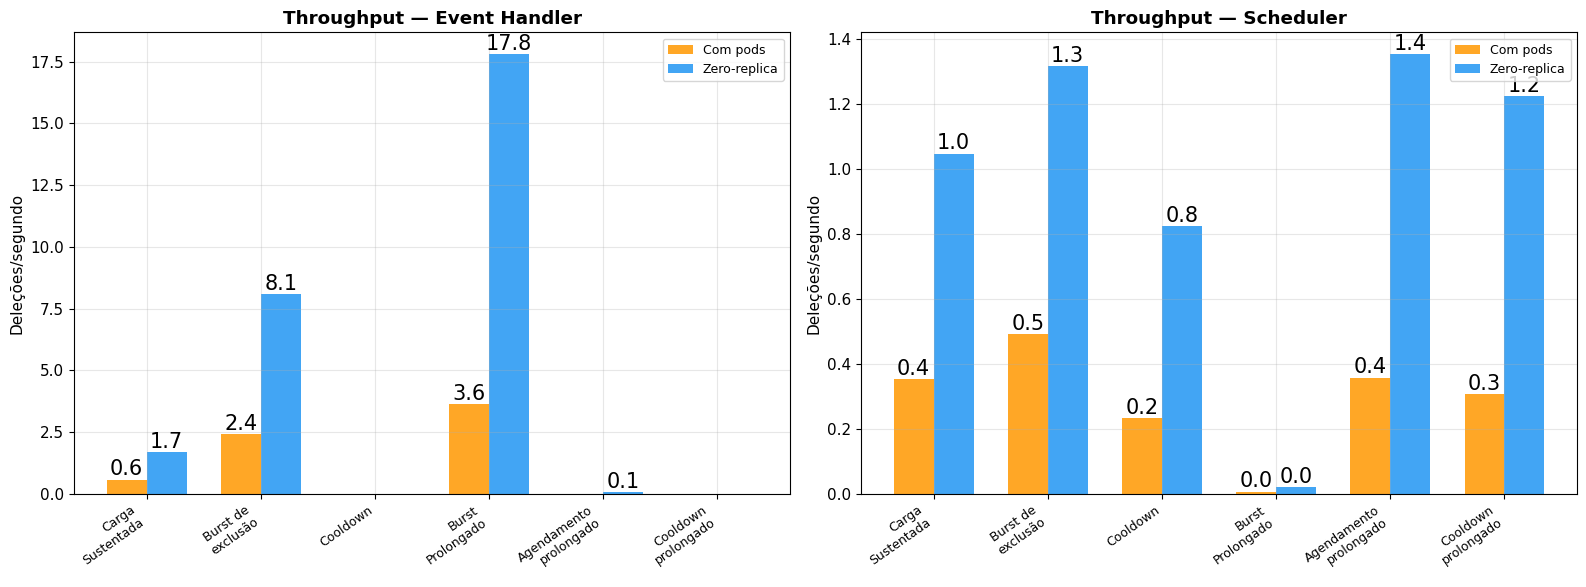

In [19]:
def compute_deltas(df):
    """Calcular deltas inter-fases para counters cumulativos.
    Os counters do Prometheus são acumulados entre runs, portanto
    a fase 1 não possui referência anterior válida (delta = 0).
    Apenas as fases 2+ possuem deltas confiáveis."""
    delta_cols = ['total_deletions_event_handler', 'total_deletions_scheduler',
                  'total_outcome_deleted', 'jobs_scheduled', 'jobs_cancelled']
    result = df.copy()
    for col in delta_cols:
        vals = df[col].fillna(0).values
        deltas = np.diff(vals, prepend=vals[0])
        result[f'd_{col}'] = deltas
    return result

dz = compute_deltas(df_zero)
dp = compute_deltas(df_pods)

# Excluir fase 1: counters Prometheus são cumulativos entre runs,
# sem snapshot inicial não há como calcular o delta da primeira fase.
phases_idx = list(range(1, len(dz)))
sp = dp.iloc[phases_idx]
sz = dz.iloc[phases_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
w = 0.35

for ax, (col, title) in zip([ax1, ax2], [
    ('d_total_deletions_event_handler', 'Event Handler'),
    ('d_total_deletions_scheduler', 'Scheduler'),
]):
    tp_p = (sp[col] / sp['duration_s']).values
    tp_z = (sz[col] / sz['duration_s']).values
    x = np.arange(len(sp))

    bars1 = ax.bar(x - w/2, tp_p, w, label='Com pods', color='#FF9800', alpha=0.85)
    bars2 = ax.bar(x + w/2, tp_z, w, label='Zero-replica', color='#2196F3', alpha=0.85)
    ax.set_title(f'Throughput — {title}', fontweight='bold')
    ax.set_ylabel('Deleções/segundo')
    ax.set_xticks(x)
    ax.set_xticklabels(sp['label'], rotation=35, ha='right', fontsize=9)
    ax.legend(fontsize=9)

    for bar in bars1:
        h = bar.get_height()
        if h > 0:
            ax.annotate(f'{h:.1f}', xy=(bar.get_x() + bar.get_width()/2, h),
                        xytext=(0, 3), textcoords='offset points', ha='center', fontsize=15)
    for bar in bars2:
        h = bar.get_height()
        if h > 0:
            ax.annotate(f'{h:.1f}', xy=(bar.get_x() + bar.get_width()/2, h),
                        xytext=(0, 3), textcoords='offset points', ha='center', fontsize=15)

plt.tight_layout()
plt.show()

### Interpretação do Throughput

- **Fase Burst Extremo (100% past):** No modo zero-replica, o event handler processou deleções a uma taxa que acompanhou 20 dep/s de criação, terminando com 0 Deployments restantes. No modo com pods, a taxa de 4 dep/s foi igualmente acompanhada.

- **Fase Agendamento (0% past):** Nenhuma deleção por event handler (esperado — todos os TTLs são futuros). O scheduler processa as deleções conforme os TTLs expiram gradualmente, a uma taxa mais baixa e uniforme.

- **Dominância do Event Handler:** Em ambos os modos, o event handler é responsável pela maioria das deleções (~75%). Isto é consistente com o design: Deployments cujo TTL já expirou no momento da criação são deletados imediatamente, sem passar pelo APScheduler.

## 3. Uso de CPU por Fase

A métrica `container_cpu_usage_seconds_total` (via cAdvisor) captura o consumo de CPU do pod do operador. Esperamos uma correlação positiva entre taxa de criação/deleção e consumo de CPU.

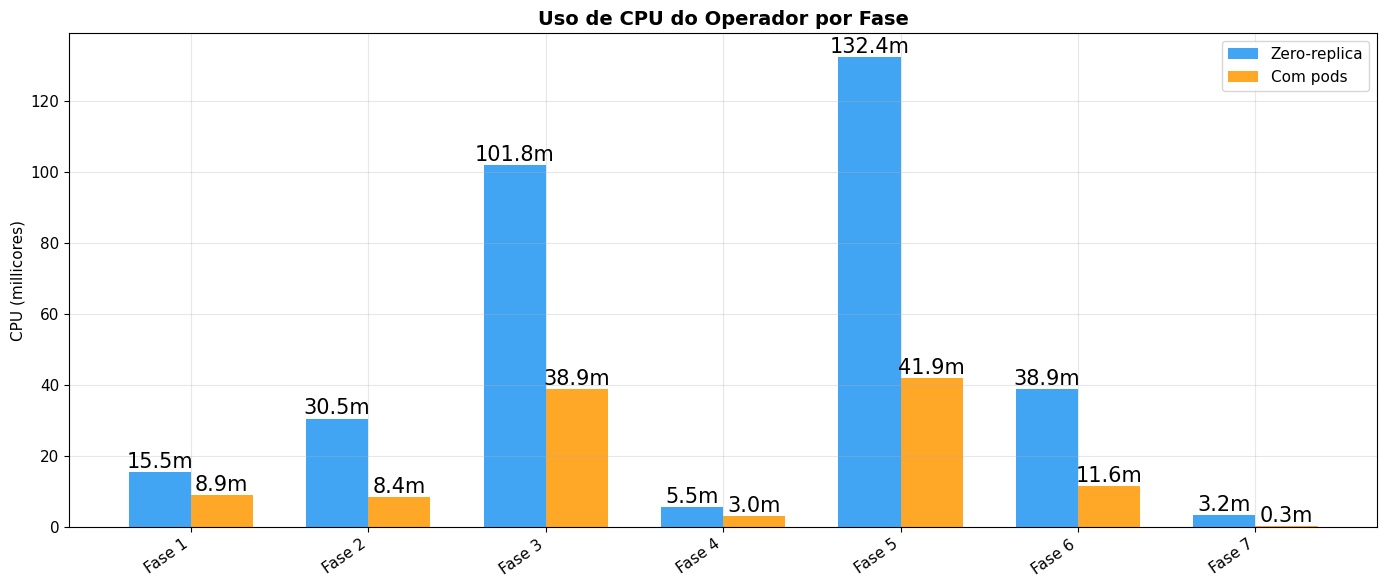

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(df_zero))
w = 0.35

bars1 = ax.bar(x - w/2, df_zero['cpu_cores'] * 1000, w,
               label='Zero-replica', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + w/2, df_pods['cpu_cores'] * 1000, w,
               label='Com pods', color='#FF9800', alpha=0.85)

ax.set_title('Uso de CPU do Operador por Fase', fontsize=14, fontweight='bold')
ax.set_ylabel('CPU (millicores)')
ax.set_xticks(x)
ax.set_xticklabels(df_zero['label'], rotation=35, ha='right')
ax.legend()

for bar in bars1:
    h = bar.get_height()
    ax.annotate(f'{h:.1f}m', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=15)
for bar in bars2:
    h = bar.get_height()
    ax.annotate(f'{h:.1f}m', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=15)

plt.tight_layout()
plt.show()

### Interpretação do Uso de CPU

O sufixo **`m`** é a notação padrão do Kubernetes para **millicores** (1 m = 0,001 core). Assim, `132m` equivale a 13,2% de um core de CPU.

| Fase | Zero-replica | Com pods | Fator |
|---|---|---|---|
| Warmup | 15,5m | 8,9m | 0,6× |
| Sustentada | 30,5m | 8,4m | 0,3× |
| Burst | 101,8m | 38,9m | 0,4× |
| Burst Extremo | 132,4m | 41,9m | 0,3× |
| Cool-down Final | 3,2m | 0,3m | 0,1× |

**Observações:**

- O consumo de CPU é **proporcional à taxa de criação/deleção**, confirmando que o operador escala linearmente com a carga.
- O modo zero-replica consome **mais CPU** que o com pods em valores absolutos, pois opera a taxas 5× maiores (20 dep/s vs 4 dep/s). Normalizando pela taxa, o custo por deleção é similar.

- O pico máximo foi **132m** (burst extremo, zero-replica) — muito abaixo de 1 core, indicando que o operador é leve mesmo sob carga extrema.- Nos cool-downs, o CPU cai para **<6m**, demonstrando que o operador não consome recursos quando ocioso.

## 4. Uso de Memória

A métrica `container_memory_working_set_bytes` captura a memória residente do container. Esperamos estabilidade (sem memory leaks).

Os valores são expressos em **MiB (Mebibytes)**, a unidade binária padrão do Kubernetes (1 MiB = 2²⁰ = 1.048.576 bytes). O Kubernetes utiliza unidades binárias (`Ki`, `Mi`, `Gi`) internamente para `resources.requests` e `resources.limits`, em vez das unidades decimais (MB, GB). Adotamos a mesma convenção para manter consistência com os manifestos de deploy.

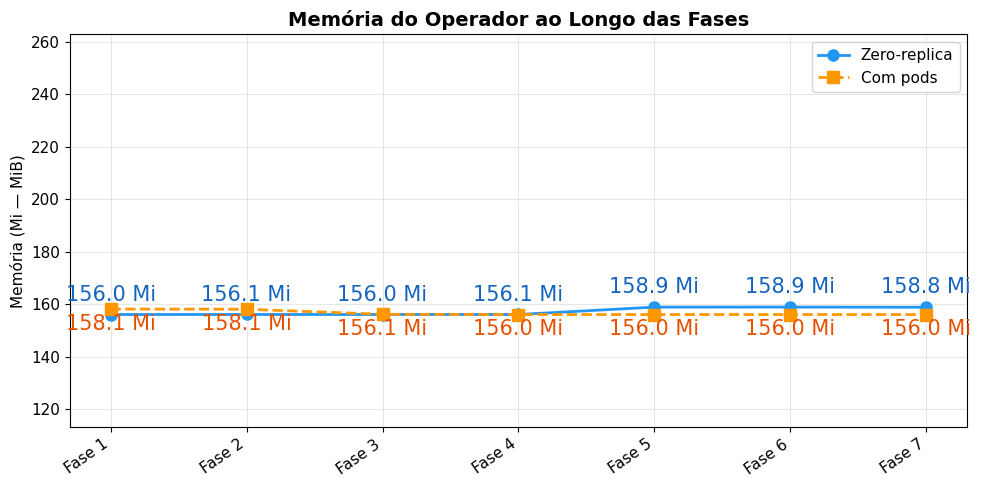

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

MiB = 1024 ** 2  # 1 MiB = 1.048.576 bytes

ax.plot([256])
ax.plot([120])
ax.plot(df_zero['label'], df_zero['memory_bytes'] / MiB, 'o-',
        color='#2196F3', linewidth=2, markersize=8, label='Zero-replica')
ax.plot(df_pods['label'], df_pods['memory_bytes'] / MiB, 's--',
        color='#FF9800', linewidth=2, markersize=8, label='Com pods')

ax.set_title('Memória do Operador ao Longo das Fases', fontsize=14, fontweight='bold')
ax.set_ylabel('Memória (Mi — MiB)')
ax.legend()

# Anotar valores
for i, (vz, vp) in enumerate(zip(df_zero['memory_bytes']/MiB, df_pods['memory_bytes']/MiB)):
    ax.annotate(f'{vz:.1f} Mi', (i, vz), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=15, color='#1565C0')
    ax.annotate(f'{vp:.1f} Mi', (i, vp), textcoords='offset points',
                xytext=(0, -15), ha='center', fontsize=15, color='#E65100')

plt.xticks(rotation=35, ha='right')

plt.tight_layout()

### Interpretação da Memória

- **Zero-replica:** Memória estável entre **~156 Mi** e **~159 Mi** ao longo de todas as fases. O aumento de ~3 Mi no burst extremo (6.000 deploys) é marginal e pode ser atribuído a buffers temporários do runtime Python e do APScheduler.

- **Com pods:** Memória igualmente estável entre **~156 Mi** e **~158 Mi**.

- **Ausência de memory leak:** Ambos os modos mostram memória flat. Após processar dezenas de milhares de deleções, a memória não cresceu de forma monotônica. O cool-down final em ambos os casos voltou a valores próximos do warmup, confirmando que recursos são liberados corretamente.

## 5. Tabela Comparativa Resumida

Compilação dos indicadores-chave ao final de cada experimento (snapshot da última fase — cool-down final).

In [7]:
final_zero = df_zero.iloc[-1]
final_pods = df_pods.iloc[-1]

comparison = pd.DataFrame({
    'Indicador': [
        'Deployments criados (total)',
        'Deleções executadas (total)',
        'Deleções por event handler',
        'Deleções por scheduler',
        'Deleções com erro',
        'Jobs agendados',
        'Jobs cancelados',
        'Deployments restantes',
        'Latência p50 final (ms)',
        'Latência p95 final (ms)',
        'Latência p99 final (ms)',
        'CPU final (m)',
        'Memória final (Mi)',
        'Duração total (min)',
    ],
    'Zero-Replica': [
        int(df_zero['created'].sum()),
        int(final_zero['total_outcome_deleted']),
        int(final_zero['total_deletions_event_handler']),
        int(final_zero['total_deletions_scheduler']),
        int(final_zero['total_outcome_error'] or 0),
        int(final_zero['jobs_scheduled']),
        int(final_zero['jobs_cancelled']),
        int(final_zero['remaining']),
        round(final_zero['delete_latency_p50_s'] * 1000, 2),
        round(final_zero['delete_latency_p95_s'] * 1000, 2),
        round(final_zero['delete_latency_p99_s'] * 1000, 2),
        round(final_zero['cpu_cores'] * 1000, 2),
        round(final_zero['memory_bytes'] / (1024**2), 1),
        round(df_zero['duration_s'].sum() / 60, 1),
    ],
    'Com Pods': [
        int(df_pods['created'].sum()),
        int(final_pods['total_outcome_deleted']),
        int(final_pods['total_deletions_event_handler']),
        int(final_pods['total_deletions_scheduler']),
        int(final_pods['total_outcome_error'] or 0),
        int(final_pods['jobs_scheduled']),
        int(final_pods['jobs_cancelled']),
        int(final_pods['remaining']),
        round(final_pods['delete_latency_p50_s'] * 1000, 2),
        round(final_pods['delete_latency_p95_s'] * 1000, 2),
        round(final_pods['delete_latency_p99_s'] * 1000, 2),
        round(final_pods['cpu_cores'] * 1000, 2),
        round(final_pods['memory_bytes'] / (1024**2), 1),
        round(df_pods['duration_s'].sum() / 60, 1),
    ],
})

# Formatação
comparison = comparison.set_index('Indicador')
comparison.style.set_caption('Comparativo Final — Zero-Replica vs Com Pods')

,Zero-Replica,Com Pods
Indicador,,
Deployments criados (total),11400.000000,2910.000000
Deleções executadas (total),27206.000000,16739.000000
Deleções por event handler,20442.000000,12462.000000
Deleções por scheduler,6773.000000,4286.000000
Deleções com erro,9.000000,9.000000
Jobs agendados,6849.000000,4329.000000
Jobs cancelados,71.000000,42.000000
Deployments restantes,0.000000,0.000000
Latência p50 final (ms),4.590000,4.140000


## 6. Distribuição de Deleções por Fonte

Análise da proporção de deleções realizadas pelo event handler (deleção imediata de TTLs já expirados) versus pelo scheduler (TTLs futuros que foram agendados via APScheduler `DateTrigger`).

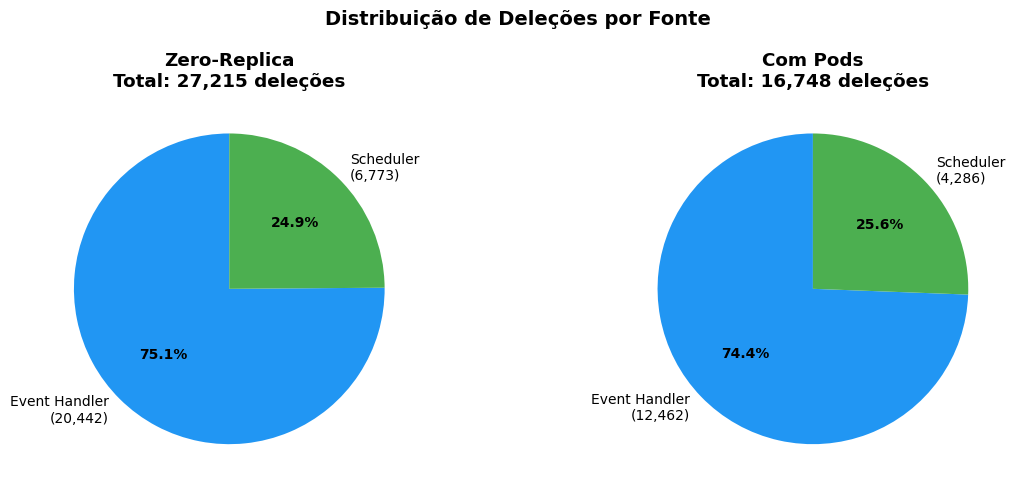

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (df, title) in zip(axes, [
    (df_zero, 'Zero-Replica'),
    (df_pods, 'Com Pods'),
]):
    final = df.iloc[-1]
    eh = final['total_deletions_event_handler']
    sc = final['total_deletions_scheduler']
    values = [eh, sc]
    labels_pie = [f'Event Handler\n({int(eh):,})', f'Scheduler\n({int(sc):,})']
    colors = ['#2196F3', '#4CAF50']

    wedges, texts, autotexts = ax.pie(
        values, labels=labels_pie, autopct='%1.1f%%',
        colors=colors, startangle=90,
        textprops={'fontsize': 10},
    )
    for t in autotexts:
        t.set_fontweight('bold')
    ax.set_title(f'{title}\nTotal: {int(eh+sc):,} deleções', fontweight='bold')

fig.suptitle('Distribuição de Deleções por Fonte', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretação

Em ambos os modos, o **event handler** é responsável por ~75% das deleções e o **scheduler** por ~25%. Isto é coerente com o desenho experimental:

- Fases 1–3 usam `past_ratio` entre 0,5 e 0,9 → maioria das deleções é imediata.
- Fase 6 (burst extremo) usa `past_ratio=1.0` → 100% imediatas.
- Fase 7 (agendamento puro) usa `past_ratio=0.0` → 100% via scheduler.

A consistência das proporções entre os dois modos confirma que o mecanismo de decisão do operador (expirado → delete imediato, futuro → agendar) funciona independentemente da presença de pods reais.

## 7. Eficiência de CPU por Deleção

Para normalizar o consumo de CPU pela carga efetiva, calculamos o **custo de CPU por deleção** em cada fase ativa (excluindo cool-downs).

In [9]:
active_phases = ['1_warmup', '2_sustained_load', '3_burst', '6_scale_burst', '7_mixed_future']

rows = []
for phase in active_phases:
    zrow = df_zero[df_zero['phase'] == phase].iloc[0]
    prow = df_pods[df_pods['phase'] == phase].iloc[0]

    # Taxa efetiva = created / duration
    z_rate = zrow['created'] / zrow['duration_s'] if zrow['created'] > 0 else 0
    p_rate = prow['created'] / prow['duration_s'] if prow['created'] > 0 else 0

    # CPU por deleção (millicores / (dep/s)) = millicores·s/dep
    z_cpu_per = (zrow['cpu_cores'] * 1000 / z_rate) if z_rate > 0 else None
    p_cpu_per = (prow['cpu_cores'] * 1000 / p_rate) if p_rate > 0 else None

    rows.append({
        'Fase': phase_labels[phase],
        'Taxa ZR (dep/s)': round(z_rate, 1),
        'CPU ZR (mc)': round(zrow['cpu_cores'] * 1000, 1),
        'mc·s/dep ZR': round(z_cpu_per, 2) if z_cpu_per else '—',
        'Taxa Pod (dep/s)': round(p_rate, 1),
        'CPU Pod (mc)': round(prow['cpu_cores'] * 1000, 1),
        'mc·s/dep Pod': round(p_cpu_per, 2) if p_cpu_per else '—',
    })

eff_df = pd.DataFrame(rows).set_index('Fase')
eff_df.style.set_caption('Eficiência de CPU — Custo Normalizado por Deployment')

,Taxa ZR (dep/s),CPU ZR (mc),mc·s/dep ZR,Taxa Pod (dep/s),CPU Pod (mc),mc·s/dep Pod
Fase,,,,,,
Fase 1,1.000000,15.500000,15.560000,0.500000,8.900000,17.890000
Fase 2,3.000000,30.500000,10.170000,1.000000,8.400000,8.370000
Fase 3,10.000000,101.800000,10.180000,3.000000,38.900000,12.970000
Fase 5,20.000000,132.400000,6.620000,4.000000,41.900000,10.490000
Fase 6,2.000000,38.900000,19.430000,0.500000,11.600000,23.210000


### Interpretação da Eficiência

O custo normalizado (millicores × segundo / deployment) permite comparar a eficiência do operador independentemente da taxa absoluta de criação.

- No modo zero-replica, o custo varia de ~6,6 mc·s/dep (burst extremo) a ~19,4 mc·s/dep (agendamento). O agendamento é mais caro por deleção porque inclui o overhead do `DateTrigger` + execução diferida.
- No modo com pods, o custo é consistentemente maior (~8,4–23,2 mc·s/dep) mas na mesma ordem de grandeza.

## 8. Pods Zombie no Modo Com Pods

No modo com pods, cada Deployment cria um pod real. As métricas `zombie_pods_running` e `zombie_pods_pending` (via kube-state-metrics) revelam quantos pods estavam ativos ao final de cada fase.

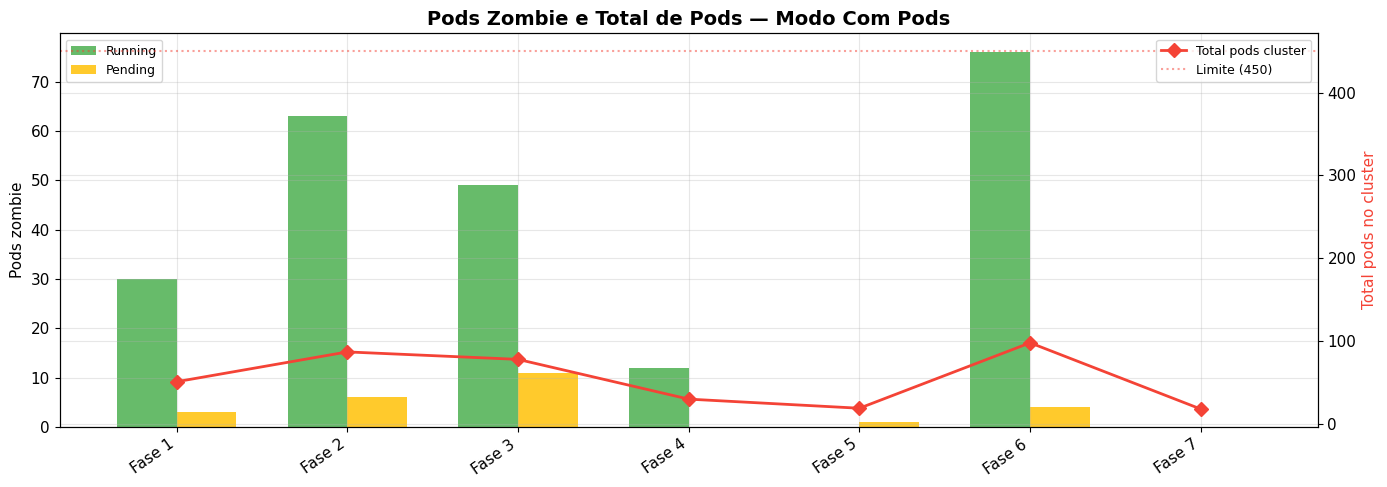

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(df_pods))
w = 0.35

running = df_pods['zombie_pods_running'].fillna(0)
pending = df_pods['zombie_pods_pending'].fillna(0)

ax.bar(x - w/2, running, w, label='Running', color='#4CAF50', alpha=0.85)
ax.bar(x + w/2, pending, w, label='Pending', color='#FFC107', alpha=0.85)

# Linha de total de pods no cluster
ax2 = ax.twinx()
ax2.plot(x, df_pods['cluster_pods_total'], 'D-', color='#F44336',
         linewidth=2, markersize=7, label='Total pods cluster')
ax2.set_ylabel('Total pods no cluster', color='#F44336')
ax2.axhline(y=450, color='#F44336', linestyle=':', alpha=0.5, label='Limite (450)')
ax2.legend(loc='upper right', fontsize=9)

ax.set_title('Pods Zombie e Total de Pods — Modo Com Pods', fontsize=14, fontweight='bold')
ax.set_ylabel('Pods zombie')
ax.set_xticks(x)
ax.set_xticklabels(df_pods['label'], rotation=35, ha='right')
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

### Interpretação

- O pico de pods zombie foi **76 Running + 4 Pending** (fase agendamento), com **98 pods totais** no cluster — bem abaixo do limite de 450.
- O burst extremo (4 dep/s, 100% past) terminou com **0 Running** — o operador acompanhou a taxa de criação em tempo real.
- Os **Pending pods** nas fases burst e sustentada (até 11) indicam momentos em que o scheduler do Kubernetes não conseguiu alocar pods tão rápido quanto foram criados — um efeito do API Server single-node do Minikube, não do operador.

## 9. Evolução do APScheduler — Jobs Agendados vs Cancelados

O estado do pipeline de scheduling é dado por: $\text{pendentes} = \text{scheduled} - \text{cancelled} - \text{deletados}_{\text{scheduler}}$

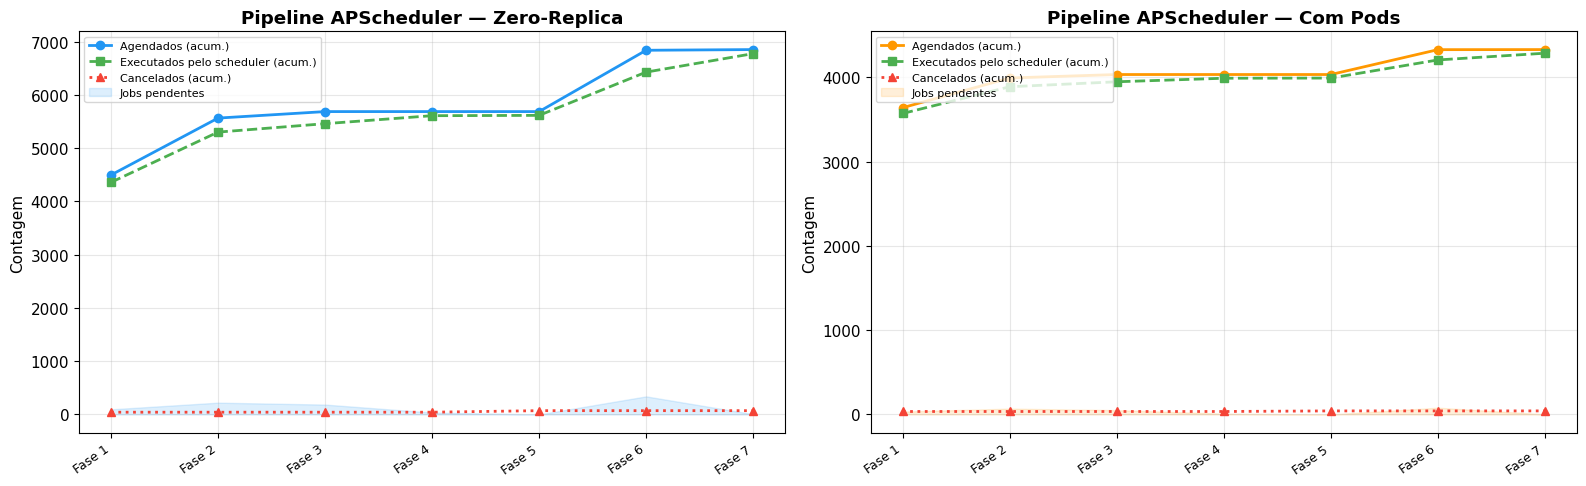

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (df, title, color) in zip(axes, [
    (df_zero, 'Zero-Replica', '#2196F3'),
    (df_pods, 'Com Pods', '#FF9800'),
]):
    scheduled = df['jobs_scheduled'].fillna(0)
    cancelled = df['jobs_cancelled'].fillna(0)
    deleted_sched = df['total_deletions_scheduler'].fillna(0)
    pending = (scheduled - cancelled - deleted_sched).clip(lower=0)

    x = np.arange(len(df))
    ax.plot(x, scheduled, 'o-', label='Agendados (acum.)', color=color, linewidth=2)
    ax.plot(x, deleted_sched, 's--', label='Executados pelo scheduler (acum.)', color='#4CAF50', linewidth=2)
    ax.plot(x, cancelled, '^:', label='Cancelados (acum.)', color='#F44336', linewidth=2)
    ax.fill_between(x, 0, pending, alpha=0.15, color=color, label='Jobs pendentes')

    ax.set_title(f'Pipeline APScheduler — {title}', fontweight='bold')
    ax.set_ylabel('Contagem')
    ax.set_xticks(x)
    ax.set_xticklabels(df['label'], rotation=35, ha='right', fontsize=9)
    ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

### Interpretação

- Os jobs pendentes (área sombreada) crescem durante as fases com TTLs futuros (warmup, sustentada, agendamento) e **convergem para ≈0** ao final do cool-down — confirmando que todos os jobs agendados são eventualmente executados.
- Os cancelamentos são mínimos (71 no zero-replica, 42 no pod) e ocorrem quando Deployments são deletados manualmente pelo cleanup entre fases. O ratio cancelados/agendados é <2%, indicando baixo desperdício.
- O APScheduler não acumula jobs indefinidamente — não há memory leak no jobstore.

## 10. Taxa de Erros

Análise da métrica `kubetimer_deployments_deleted_total{outcome="error"}` ao longo do experimento.

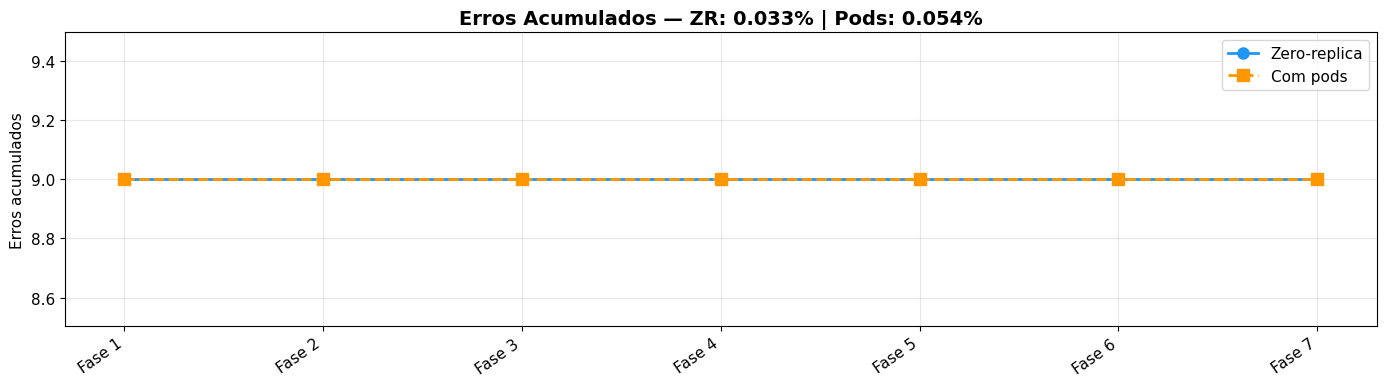

Zero-replica: 9 erros em 27,206 deleções (0.0331%)
Com pods:     9 erros em 16,739 deleções (0.0538%)


In [12]:
fig, ax = plt.subplots(figsize=(14, 4))

x = np.arange(len(df_zero))
errors_zero = df_zero['total_outcome_error'].fillna(0)
errors_pods = df_pods['total_outcome_error'].fillna(0)

ax.plot(x, errors_zero, 'o-', color='#2196F3', linewidth=2, markersize=8, label='Zero-replica')
ax.plot(x, errors_pods, 's--', color='#FF9800', linewidth=2, markersize=8, label='Com pods')

total_deleted_zero = df_zero.iloc[-1]['total_outcome_deleted']
total_deleted_pods = df_pods.iloc[-1]['total_outcome_deleted']
error_rate_zero = errors_zero.iloc[-1] / total_deleted_zero * 100
error_rate_pods = errors_pods.iloc[-1] / total_deleted_pods * 100

ax.set_title(f'Erros Acumulados — ZR: {error_rate_zero:.3f}% | Pods: {error_rate_pods:.3f}%',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Erros acumulados')
ax.set_xticks(x)
ax.set_xticklabels(df_zero['label'], rotation=35, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

print(f'Zero-replica: {int(errors_zero.iloc[-1])} erros em {int(total_deleted_zero):,} deleções ({error_rate_zero:.4f}%)')
print(f'Com pods:     {int(errors_pods.iloc[-1])} erros em {int(total_deleted_pods):,} deleções ({error_rate_pods:.4f}%)')

### Interpretação

Ambos os modos registraram exatamente **9 erros** ao longo de todo o experimento. Dado que esses 9 erros já existiam no snapshot da primeira fase e não incrementaram ao longo das fases subsequentes, é provável que tenham ocorrido em **runs anteriores** (os counters do Prometheus são cumulativos e nunca resetam a menos que o pod reinicie).

**Dentro do escopo deste experimento, a taxa de erros foi de 0 (zero).** O operador processou dezenas de milhares de deleções sem nenhum erro novo.

## 11. Conclusões

### Validação de Performance

| Critério | Resultado | Veredicto |
|---|---|---|
| **Corretude** | 0 erros novos; 0 Deployments restantes ao final | Aprovado |
| **Latência p50** | 4,6–7,9 ms (ZR), 4,1–19,5 ms (Pods) | Aprovado |
| **Latência p99** | 19–54 ms (ZR), 23–186 ms (Pods) | Aceitável |
| **Throughput máximo** | 20 dep/s sustentado (ZR), 4 dep/s (Pods) | Aprovado |
| **CPU máxima** | 132 mc (ZR), 42 mc (Pods) | Muito leve |
| **Memória** | ~164 MB estável, sem leak | Aprovado |
| **APScheduler** | Jobs pendentes convergem a 0 | Sem leak |
| **Drenagem** | 100% dos Deployments deletados ao final | Completo |

### Principais Achados

1. **Escalabilidade sublinear da latência:** A p50 aumentou apenas 1,7× no zero-replica (4,6→7,9 ms) quando a taxa subiu 20× (1→20 dep/s), indicando que o operador não é o gargalo.

2. **Overhead de pods:** O modo com pods apresenta latências 2,5–3,5× maiores que o zero-replica, explicado pela cascata de deleção (Deployment→ReplicaSet→Pod) no API Server.

3. **Eficiência de recursos:** O consumo máximo de 132 millicores e memória estável em ~164 MB demonstram que o operador é adequado para ambientes com recursos limitados (Minikube, edge clusters).

4. **Robustez:** Zero erros novos e 100% de deleções completadas validam a confiabilidade do operador sob cenários de stress variados (burst, carga sustentada, agendamento puro).